## 1. Data Understanding and exploration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm

In [2]:
dataset = pd.read_csv('day.csv')
dataset.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [3]:
dataset['season'] = dataset['season'].map({
    1:'spring',
    2:'summer',
    3:'fall',
    4:'winter'
})

dataset['mnth'] = dataset['mnth'].map({
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',
    5:'May',6:'Jun',7:'Jul',8:'Aug',
    9:'Sep',10:'Oct',11:'Nov',12:'Dec'
})

dataset['weekday'] = dataset['weekday'].map({
    0:'Sun',
    1:'Mon',
    2:'Tue',
    3:'Wed',
    4:'Thu',
    5:'Fri',
    6:'Sat'
})

dataset['weathersit'] = dataset['weathersit'].map({
    1:'Clear',
    2:'Cloudy',
    3:'Rainy'
})

In [4]:
dataset.drop(['instant','dteday','atemp'], axis=1, inplace=True)

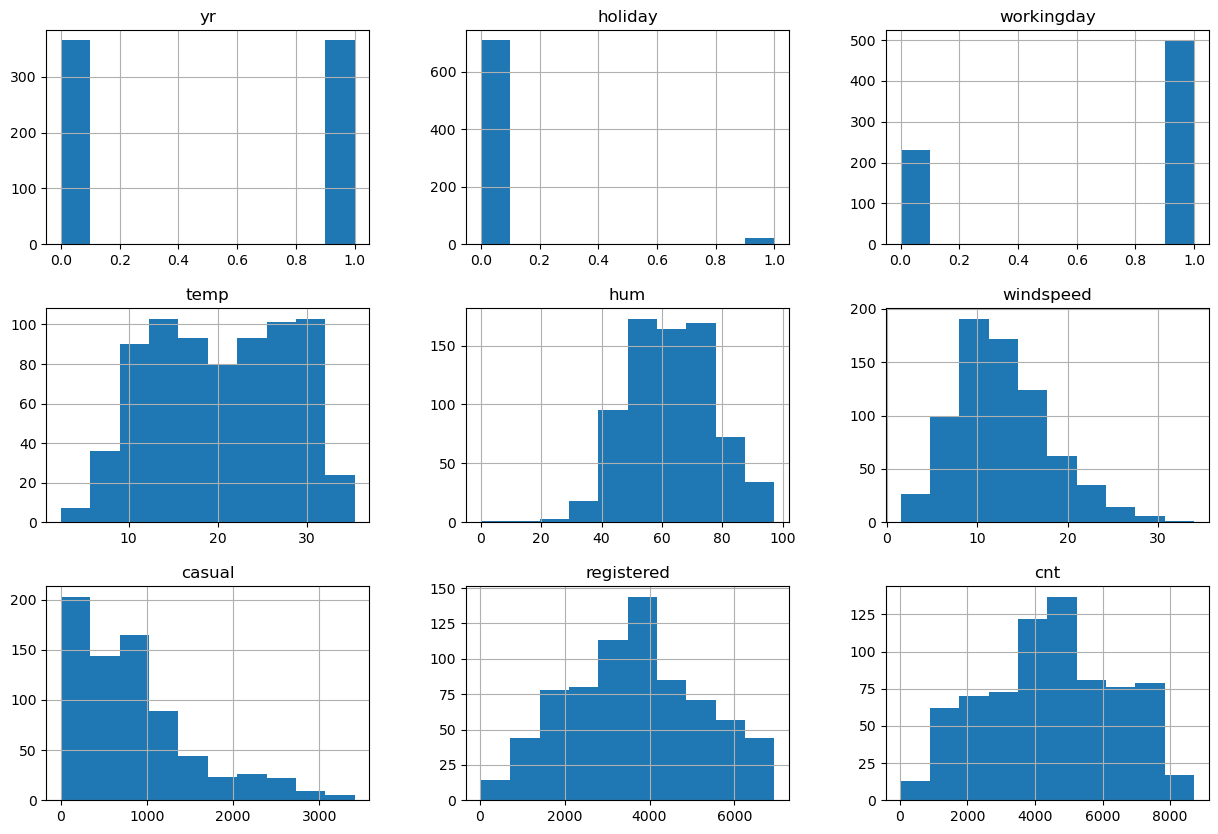

In [5]:
dataset.hist(figsize=(15,10))
plt.show()

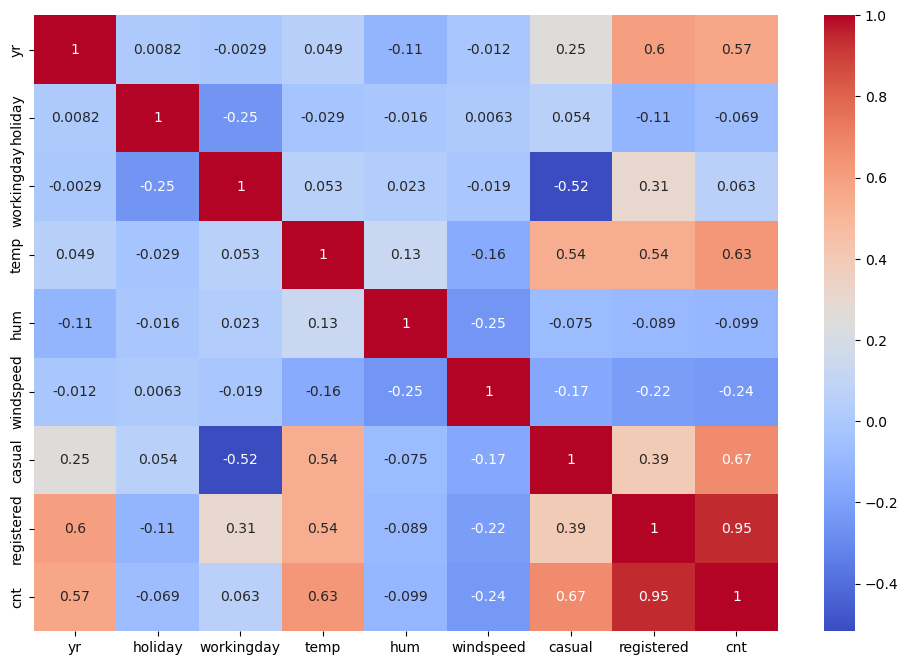

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

In [7]:
dataset = pd.get_dummies(dataset, drop_first=True)
dataset.head()

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,season_spring,...,mnth_Oct,mnth_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_Cloudy,weathersit_Rainy
0,0,0,0,14.110847,80.5833,10.749882,331,654,985,True,...,False,False,False,True,False,False,False,False,True,False
1,0,0,0,14.902598,69.6087,16.652113,131,670,801,True,...,False,False,False,False,True,False,False,False,True,False
2,0,0,1,8.050924,43.7273,16.636703,120,1229,1349,True,...,False,False,True,False,False,False,False,False,False,False
3,0,0,1,8.200000,59.0435,10.739832,108,1454,1562,True,...,False,False,False,False,False,False,True,False,False,False
4,0,0,1,9.305237,43.6957,12.522300,82,1518,1600,True,...,False,False,False,False,False,False,False,True,False,False


In [8]:
X = dataset.drop(['cnt', 'casual', 'registered'], axis=1)
y = dataset['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [9]:
scaler = MinMaxScaler()

num_cols = ['temp', 'hum', 'windspeed']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})

coeff_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,temp,3864.293853
0,yr,2024.230966
8,season_winter,934.173704
19,mnth_Sep,750.723346
7,season_summer,374.037910
2,workingday,308.111183
21,weekday_Sat,302.339421
16,mnth_May,216.572173
9,mnth_Aug,179.903254
18,mnth_Oct,91.766896


In [12]:
y_pred = lr.predict(X_test)

In [13]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8276269222568877


In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 786.4698469240832


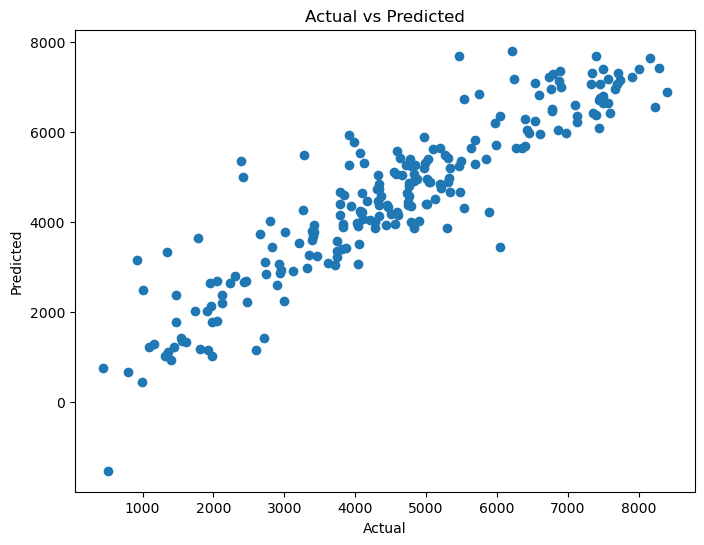

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

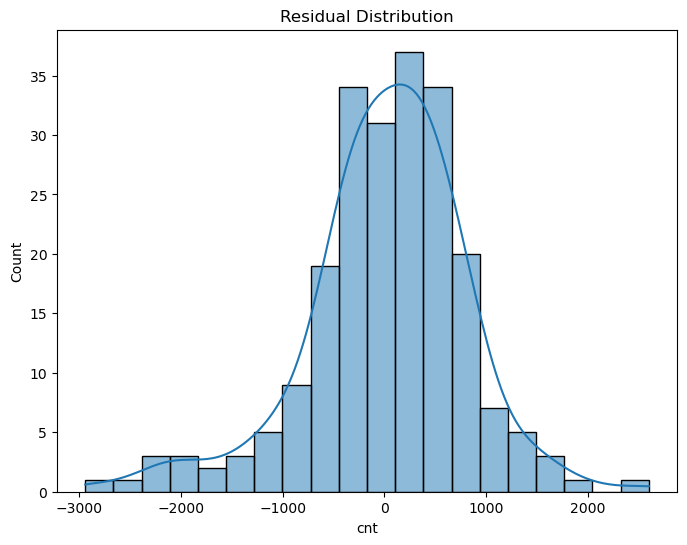

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [20]:
# Convert all columns to numeric float
X_train_sm = X_train.astype(float)

# Add constant
X_train_sm = sm.add_constant(X_train_sm)

# Ensure y is float
y_train_sm = y_train.astype(float)

# Fit OLS model
ols_model = sm.OLS(y_train_sm, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     103.6
Date:                Sat, 09 May 2026   Prob (F-statistic):          7.98e-182
Time:                        19:25:56   Log-Likelihood:                -4107.1
No. Observations:                 511   AIC:                             8270.
Df Residuals:                     483   BIC:                             8389.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2135.1071    306.91